# **2. Travel Classification**
## Coast-to-Coast Travel Analysis

This notebook:
- Classifies all 32 NFL teams by time zone
- Calculates time zones crossed for each game
- Identifies coast-to-coast travel games (3 time zones)
- Analyzes travel burden by team

**Output**: Schedule data with travel metrics added

---
## Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load schedule data from previous notebook
schedules = pd.read_csv('data_schedules.csv')

---
## **Team Time Zone with Classifications**

NFL teams distributed across 4 US time zones:
- **Pacific** (0 offset): West Coast teams
- **Mountain** (+1 hour): Denver, Arizona
- **Central** (+2 hours): Midwest and South
- **Eastern** (+3 hours): East Coast teams

In [2]:
# Team time zone mapping
team_timezones = {
    # Pacific - 5 teams
    'SEA': 'Pacific', # Seattle
    'SF': 'Pacific',  # San Francisco
    'LAC': 'Pacific', # Los Angeles Chargers
    'LAR': 'Pacific', # Los Angeles Rams
    'LV': 'Pacific',  # Las Vegas
    
    # Mountain - 2 teams
    'DEN': 'Mountain', # Denver
    'ARI': 'Mountain', # Arizona
    
    # Central - 10 teams
    'CHI': 'Central', # Chicago
    'GB': 'Central',  # Green Bay
    'MIN': 'Central', # Minnesota
    'DET': 'Central', # Detroit
    'DAL': 'Central', # Dallas
    'HOU': 'Central', # Houston
    'KC': 'Central',  # Kansas City
    'NO': 'Central', # New Orleans
    'TEN': 'Central', # Tennessee
    'IND': 'Central', # Indianapolis
    
    # Eastern - 15 teams
    'BUF': 'Eastern', # Buffalo
    'MIA': 'Eastern', # Miami
    'NE': 'Eastern',  # New England
    'NYJ': 'Eastern', # New York Jets
    'BAL': 'Eastern', # Baltimore
    'CIN': 'Eastern', # Cincinnati
    'CLE': 'Eastern', # Cleveland
    'PIT': 'Eastern', # Pittsburgh
    'ATL': 'Eastern', # Atlanta
    'CAR': 'Eastern', # Carolina
    'TB': 'Eastern',  # Tampa Bay
    'WAS': 'Eastern', # Washington
    'NYG': 'Eastern', # New York Giants
    'PHI': 'Eastern', # Philadelphia
    'JAX': 'Eastern'  # Jacksonville
}

# Time zone offsets (making Pacific the reference point)
timezone_offset = {
    'Pacific': 0,
    'Mountain': 1,
    'Central': 2,
    'Eastern': 3
}

In [3]:
# Count teams by time zone
from collections import Counter
tz_counts = Counter(team_timezones.values())

print("Teams by Time Zone:")
for tz in ['Pacific', 'Mountain', 'Central', 'Eastern']:
    print(f"  {tz} : {tz_counts[tz]} teams")

Teams by Time Zone:
  Pacific : 5 teams
  Mountain : 2 teams
  Central : 10 teams
  Eastern : 15 teams


---
## **Add Time Zones to Schedule Data**

In [4]:
# Map time zones to schedule
# In this cell we are adding the time zone information for both home and away teams in the schedule DataFrame

schedules['home_timezone'] = schedules['home_team'].map(team_timezones)
schedules['away_timezone'] = schedules['away_team'].map(team_timezones)

# Check for any unmapped teams; report if any found
unmapped = schedules[schedules['home_timezone'].isna() | schedules['away_timezone'].isna()]
if len(unmapped) > 0:
    print(f"Warning: {len(unmapped)} games with unmapped teams")
else:
    print("All teams successfully mapped to time zones")

---
## **Calculate Travel Distance**

For each game, calculate how many time zones the *away* team crossed.
- 0 zones = same time zone game
- 1 zone = short travel
- 2 zones = moderate travel
- 3 zones = **coast-to-coast** (what we are analyzing)

In [5]:
# This cell calculates the number of time zones crossed by the away team for each game in the schedule
# Calculate number of time zones traveled by away team
def calculate_tz_difference(home_tz, away_tz):

    # home_tz: Home team's time zone
    # away_tz: Away team's time zone
    if pd.isna(home_tz) or pd.isna(away_tz):
        return 0
    
    home_offset = timezone_offset.get(home_tz, 0) # This calculates the offset for the home team's time zone 
    away_offset = timezone_offset.get(away_tz, 0) # This calculates the offset for the away team's time zone
    
    return abs(home_offset - away_offset) # This returns the absolute difference in time zones

# Apply function to calculate travel, add new column to schedules DataFrame
schedules['tz_crossed'] = schedules.apply(
    lambda row: calculate_tz_difference(row['home_timezone'], row['away_timezone']),
    axis=1
)

---
## **Identify Coast-to-Coast Games**

In [6]:
# Flag coast-to-coast travel
schedules['coast_to_coast'] = schedules['tz_crossed'] == 3

# Summary statistics
print("Travel Distribution:")
print(schedules['tz_crossed'].value_counts().sort_index())
print(f"\nCoast-to-coast games: {schedules['coast_to_coast'].sum():,}")
print(f" - Percentage of all games: {schedules['coast_to_coast'].sum() / len(schedules) * 100:.1f}%")

Travel Distribution:
0    512
1    392
2    136
3     99
Name: tz_crossed, dtype: int64

Coast-to-coast games: 99
 - Percentage of all games: 8.7%


---
## **Analyze Effect of Travel by Team**

Which teams face the most coast-to-coast travel?

In [7]:
# Coast-to-coast games as AWAY team
away_c2c = schedules[schedules['coast_to_coast']].groupby('away_team').size().sort_values(ascending=False)

print("Teams with Most Coast-to-Coast AWAY Games (2021-2024):")
print(away_c2c)

Teams with Most Coast-to-Coast AWAY Games (2021-2024):
away_team
SF     14
LAC    14
LV     12
SEA     9
MIA     5
NYG     5
PIT     4
BAL     4
NE      4
TB      3
NYJ     3
ATL     3
JAX     3
CLE     3
CIN     3
CAR     3
WAS     3
PHI     2
BUF     2
dtype: int64


In [8]:
# Coast-to-coast games as HOME team
home_c2c = schedules[schedules['coast_to_coast']].groupby('home_team').size().sort_values(ascending=False)

print("Teams HOSTING Most Coast-to-Coast Games (2021-2024):")
print(home_c2c)

Teams HOSTING Most Coast-to-Coast Games (2021-2024):
home_team
LV     15
SEA    13
LAC    12
SF     10
CIN     5
PIT     5
ATL     4
PHI     4
CLE     4
JAX     4
TB      3
MIA     3
NE      3
BAL     3
WAS     3
NYJ     2
NYG     2
CAR     2
BUF     2
dtype: int64


---
## **Visualize Travel Burden**

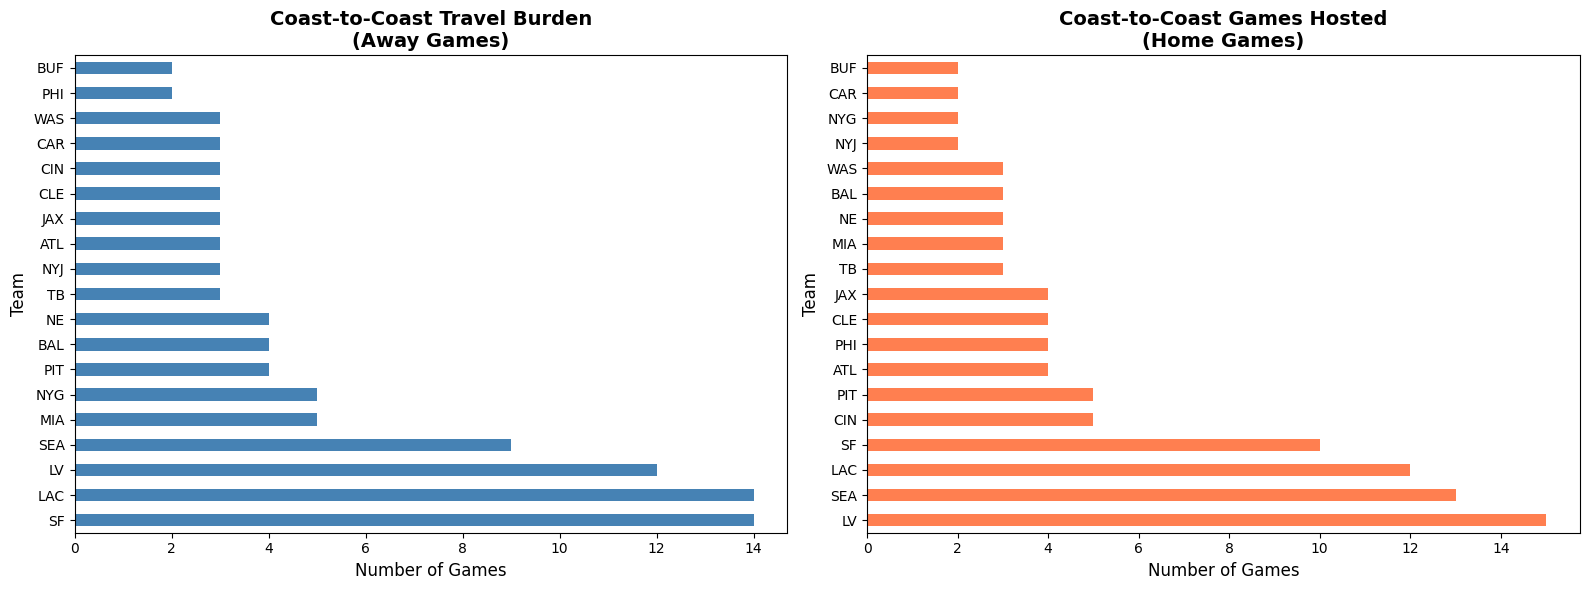

In [9]:
# Create visualization of travel burden
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Away team travel burden
away_c2c.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Coast-to-Coast Travel Burden\n(Away Games)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Games', fontsize=12)
ax1.set_ylabel('Team', fontsize=12)

# Home team hosting
home_c2c.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Coast-to-Coast Games Hosted\n(Home Games)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Games', fontsize=12)
ax2.set_ylabel('Team', fontsize=12)

plt.tight_layout()
plt.show()

---
## **East Coast vs West Coast Disparity**

In [10]:
# Classify teams by coast
# Here we classify teams into West Coast and East Coast based on their time zones
west_coast_teams = [team for team, tz in team_timezones.items() if tz == 'Pacific']
east_coast_teams = [team for team, tz in team_timezones.items() if tz == 'Eastern']

# Calculate average travel burden
# Here we calculate the average number of coast-to-coast away games for West Coast and East Coast teams
west_avg = away_c2c[away_c2c.index.isin(west_coast_teams)].mean()
east_avg = away_c2c[away_c2c.index.isin(east_coast_teams)].mean()

print("Average Coast-to-Coast Away Games per Team (2021-2024):")
print(f"  West Coast teams ({len(west_coast_teams)} teams): {west_avg:.1f} games")
print(f"  East Coast teams ({len(east_coast_teams)} teams): {east_avg:.1f} games")
print(f"\n  Disparity: West Coast teams face {west_avg - east_avg:.1f} more coast-to-coast games on average")

Average Coast-to-Coast Away Games per Team (2021-2024):
  West Coast teams (5 teams): 12.2 games
  East Coast teams (15 teams): 3.3 games

  Disparity: West Coast teams face 8.9 more coast-to-coast games on average


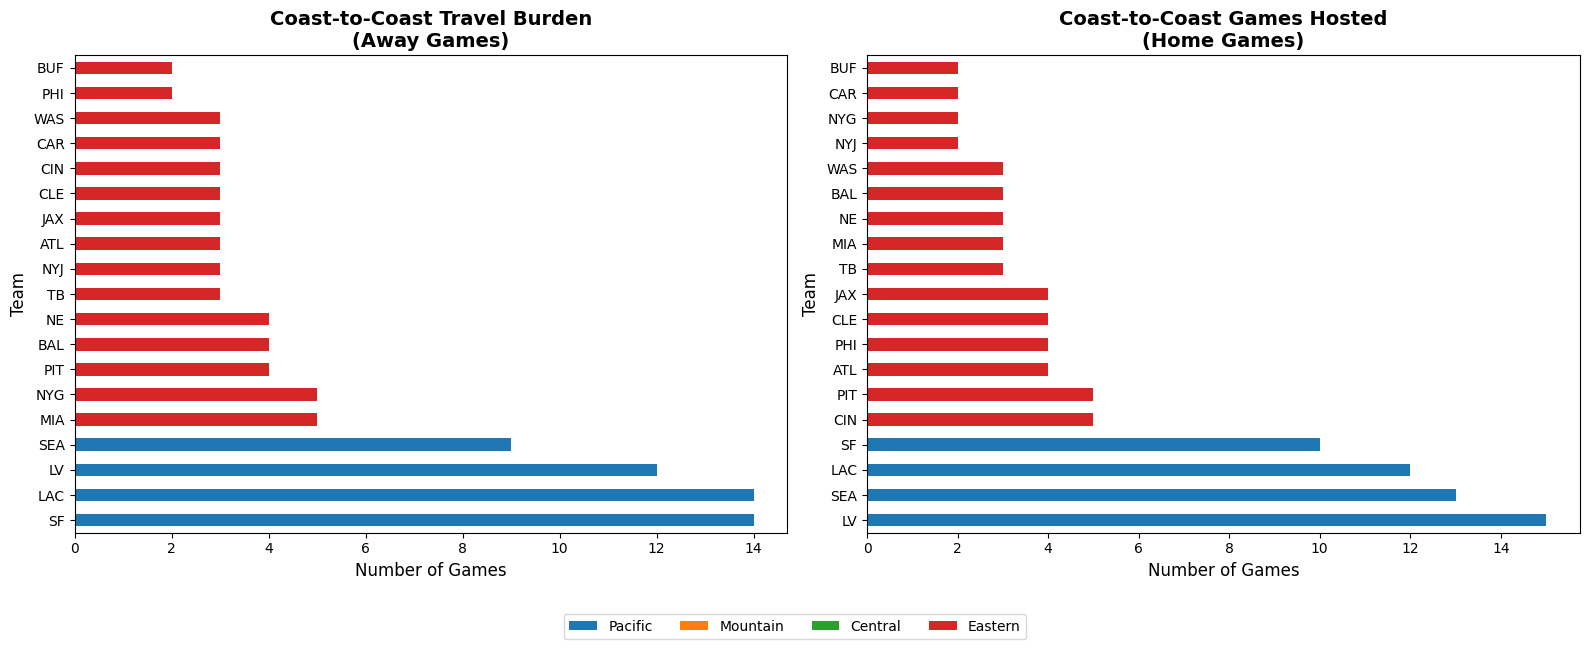

In [ ]:
# Create visualization of travel burden with time zone colors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define colors for each time zone
tz_colors = {
    'Pacific': '#1f77b4',    
    'Mountain': '#ff7f0e',   
    'Central': '#2ca02c',    
    'Eastern': '#d62728'     
}

# Away team travel burden
away_colors = [tz_colors[team_timezones[team]] for team in away_c2c.index]
away_c2c.plot(kind='barh', ax=ax1, color=away_colors)
ax1.set_title('Coast-to-Coast Travel Burden\n(Away Games)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Games', fontsize=12)
ax1.set_ylabel('Team', fontsize=12)

# Home team hosting
home_colors = [tz_colors[team_timezones[team]] for team in home_c2c.index]
home_c2c.plot(kind='barh', ax=ax2, color=home_colors)
ax2.set_title('Coast-to-Coast Games Hosted\n(Home Games)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Number of Games', fontsize=12)
ax2.set_ylabel('Team', fontsize=12)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=tz_colors[tz], label=tz) 
                   for tz in ['Pacific', 'Mountain', 'Central', 'Eastern']]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, 
           bbox_to_anchor=(0.5, -0.02), fontsize=10)

plt.tight_layout()
plt.show()

---
## **Save Enhanced Schedule Data**

In [12]:
# Save schedule with travel metrics
schedules.to_csv('data_schedules_with_travel.csv', index=False)

print("Enhanced schedule data saved as: ")
print("  - data_schedules_with_travel.csv")
print("\nNew columns added:")
print("  - home_timezone")
print("  - away_timezone")
print("  - tz_crossed")
print("  - coast_to_coast")

Enhanced schedule data saved as: 
  - data_schedules_with_travel.csv

New columns added:
  - home_timezone
  - away_timezone
  - tz_crossed
  - coast_to_coast


---
## **Summary**

**Key Findings:**
- Coast-to-coast games identified across 4 seasons
- West Coast teams face significantly more travel burden
- Clear disparity in workload between coasts

**Next Steps:**
- Measure win rates, scoring, and other metrics